In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading WindFarmA/0.csv...
  Train: 16,032 | Normal: 12,000 | Pre-failure: 4,032
  Test:  2,494  | Pre-failure: 2,206
Loading WindFarmA/3.csv...
  Train: 20,825 | Normal: 12,000 | Pre-failure: 8,825
  Test:  3,302  | Pre-failure: 0
Loading WindFarmA/10.csv...
  Train: 17,859 | Normal: 12,000 | Pre-failure: 5,859
  Test:  1,268  | Pre-failure: 1,268
Loading WindFarmA/13.csv...
  Train: 20,175 | Normal: 12,000 | Pre-failure: 8,175
  Test:  3,583  | Pre-failure: 0
Loading WindFarmA/14.csv...
  Train: 14,010 | Normal: 12,000 | Pre-failure: 2,010
  Test:  1,901  | Pre-failure: 0
Loading WindFarmA/17.csv...
  Train: 17,985 | Normal: 12,000 | Pre-failure: 5,985
  Test:  2,781  | Pre-failure: 0

Features:  106
Train:     106,886 rows | Pre-failure: 34,886
Test:      15,329 rows  | Pre-failure: 3,474

Feature list:
['sensor_0_avg', 'sensor_1_avg', 'sensor_2_avg', 'sen

H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 9 days
H2O_cluster_name:,H2O_from_python_unknownUser_d4vt0u
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
22:15:20.205: _train param, Dropping bad and constant columns: [sensor_49, sensor_46]

██████████████████████████████
22:19:59.831: _train param, Dropping bad and constant columns: [sensor_49, sensor_46]

███
22:20:28.303: _train param, Dropping bad and constant columns: [sensor_49, sensor_46]

████████████████████████████
22:25:01.257: _train param, Dropping bad and constant columns: [sensor_49, sensor_46]

██| (done) 100%

Training time: 604.4s
Peak RAM: 0.55 GB

Leaderboard (top 10):
model_id                               aucpr       auc      logloss    mean_per_class_error       rmse          mse
XGBoost_1_AutoML_1_20260421_221517  1         1         0.00690357               0           0.0340166  0.00115713
GBM_1_AutoML_1_20260421_221517      1         1         0.000215446 

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


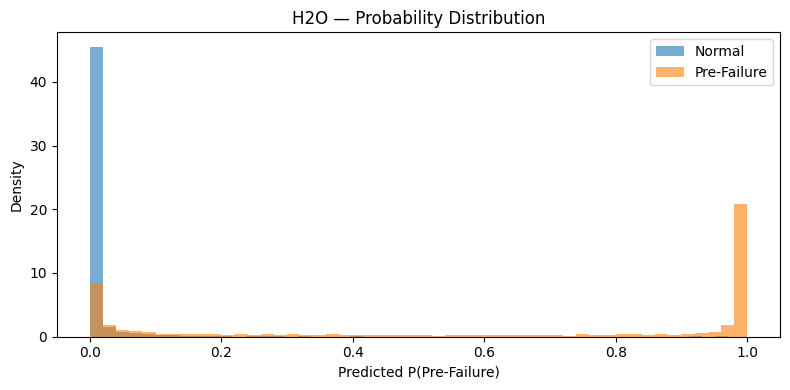

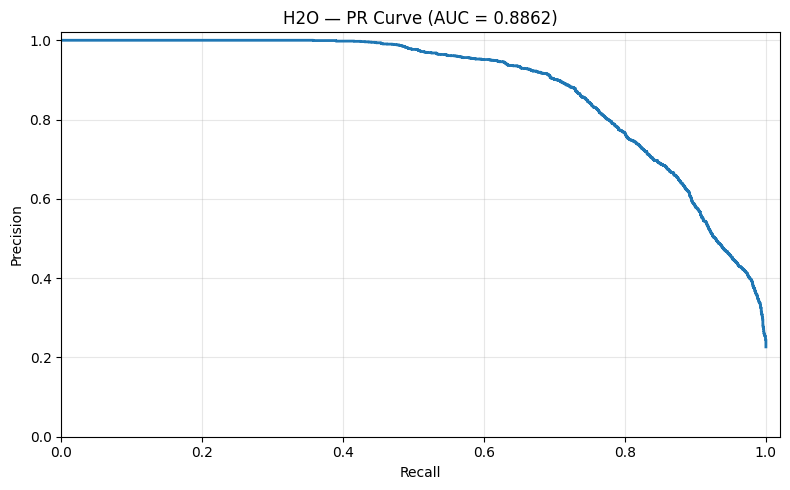


Confusion Matrix:
[[11746   109]
 [ 1364  2110]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.99      0.94     11855
 Pre-Failure       0.95      0.61      0.74      3474

    accuracy                           0.90     15329
   macro avg       0.92      0.80      0.84     15329
weighted avg       0.91      0.90      0.90     15329

ROC-AUC: 0.9453
AUCPR:   0.8862


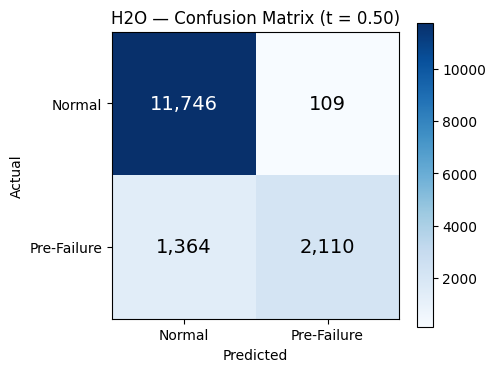

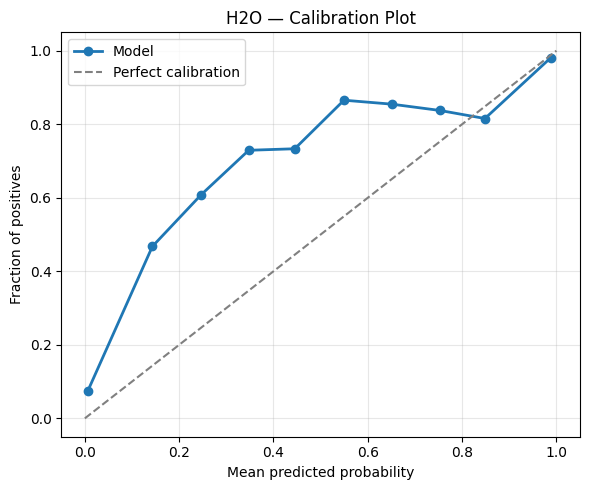


Top 20 Variable Importances:
                      variable  relative_importance  scaled_importance  \
0   sensor_53_avg_roll144_mean         13120.660156           1.000000   
1    sensor_0_avg_roll144_mean         11113.459961           0.847020   
2    sensor_6_avg_roll144_mean          8380.560547           0.638730   
3     sensor_5_avg_roll144_std          6885.707031           0.524799   
4   sensor_41_avg_roll144_mean          5924.378906           0.451531   
5   sensor_31_avg_roll144_mean          5153.146973           0.392751   
6     sensor_0_avg_roll144_std          4666.583984           0.355667   
7   sensor_19_avg_roll144_mean          3560.001953           0.271328   
8    sensor_14_avg_roll144_std          3384.927002           0.257985   
9    sensor_13_avg_roll144_std          3331.398193           0.253905   
10   sensor_5_avg_roll144_mean          3076.430664           0.234472   
11   sensor_31_avg_roll144_std          2979.559326           0.227089   
12   sen

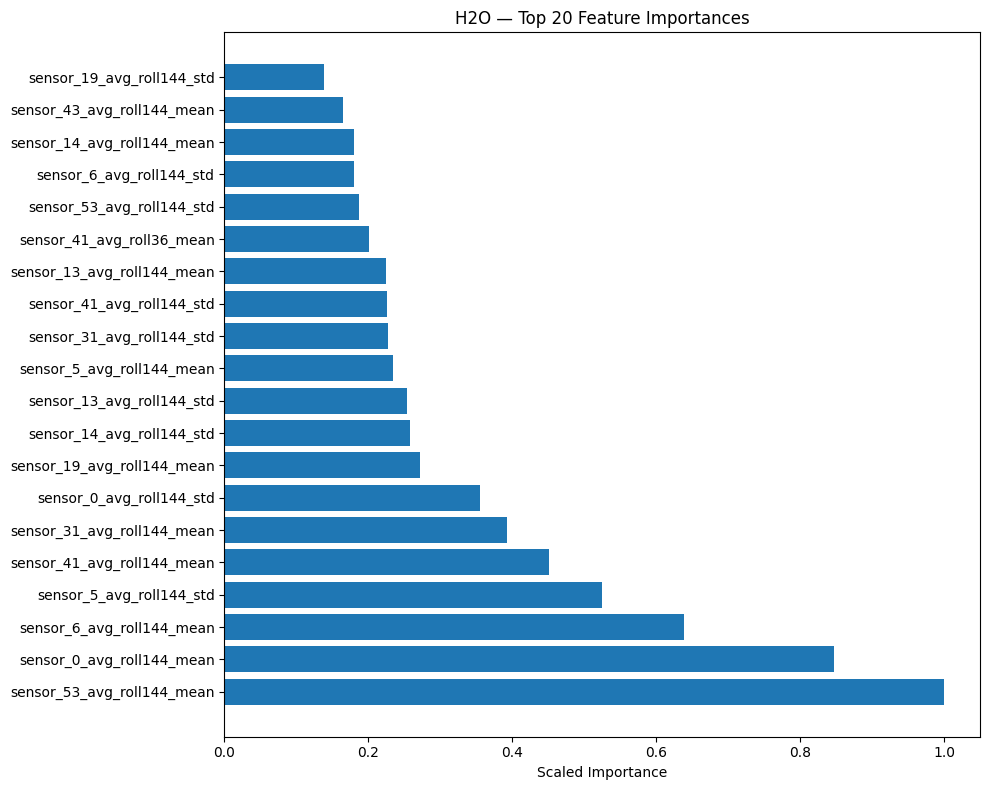


Summary — H2O
Best model:       XGBoost_1_AutoML_1_20260421_221517
Features:         106
Preprocess time:  8.26s
Training time:    604.4s
Total time:       643.3s
Python peak RAM:  1.07 GB
JVM heap cap:     4.00 GB
Total RAM usage:  ~5.07 GB
ROC-AUC:          0.9453
AUCPR:            0.8862
Threshold:        0.50 (default)
F1:               0.7413
Recall:           0.6074
Precision:        0.9509


In [ ]:
!pip install h2o --quiet

import h2o
from h2o.automl import H2OAutoML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import resource
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc
)
from sklearn.calibration import calibration_curve
from google.colab import drive

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Final_Year_Project/'

def get_peak_ram_gb():
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6

total_start = time.time()

RANDOM_SEED = 42
MAX_RUNTIME = 600
MAX_MODELS = 20
max_normal = 12_000

FILES = [
    ('WindFarmA', 0),
    ('WindFarmA', 3),
    ('WindFarmA', 10),
    ('WindFarmA', 13),
    ('WindFarmA', 14),
    ('WindFarmA', 17),
]

rolling_cols = [
    'sensor_5_avg',  'sensor_31_avg',
    'sensor_0_avg',  'sensor_43_avg',
    'sensor_53_avg', 'sensor_19_avg',
    'sensor_6_avg',  'sensor_7_avg',
    'sensor_41_avg', 'sensor_13_avg',
    'sensor_14_avg',
]
rolling_windows = [6, 36, 144]

drop_cols = [
    'time_stamp',
    'asset_id',
    'id',
    'train_test',
    'status_type_id',
    'power_29_avg', 'power_29_max', 'power_29_min', 'power_29_std',
    'power_30_avg', 'power_30_max', 'power_30_min', 'power_30_std',
    'wind_speed_3_avg', 'wind_speed_3_max', 'wind_speed_3_min', 'wind_speed_3_std',
    'wind_speed_4_avg',
    'reactive_power_27_avg', 'reactive_power_27_max', 'reactive_power_27_min', 'reactive_power_27_std',
    'reactive_power_28_avg', 'reactive_power_28_max', 'reactive_power_28_min', 'reactive_power_28_std',
    'sensor_35_avg', 'sensor_36_avg', 'sensor_37_avg',
]

# these sensors directly indicate failure, remove them
dropped_sensors = [
    'sensor_35', 'sensor_36', 'sensor_37',
    'sensor_38', 'sensor_39', 'sensor_40',
    'sensor_18', 'sensor_52',
    'sensor_23', 'sensor_25',
    'sensor_34',
    'sensor_44', 'sensor_48', 'sensor_50',
]

preprocess_start = time.time()
all_train, all_test = [], []

for farm, file_num in FILES:
    path = f'{base_path}{farm}/{file_num}.csv'
    print(f"Loading {farm}/{file_num}.csv...")

    df = pd.read_csv(path, sep=';')
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])
    df = df.sort_values('time_stamp').reset_index(drop=True)

    # drop actual failure rows, only keep normal and pre-failure
    df = df[df['status_type_id'] != 3].copy()
    df['target'] = (df['status_type_id'] == 4).astype(int)

    for col in rolling_cols:
        if col in df.columns:
            for w in rolling_windows:
                df[f'{col}_roll{w}_mean'] = df[col].rolling(w, min_periods=1).mean()
                df[f'{col}_roll{w}_std'] = df[col].rolling(w, min_periods=1).std().fillna(0)

    df = df.dropna().reset_index(drop=True)

    leaky_cols = [c for c in df.columns if any(c.startswith(root + '_') or c == root for root in dropped_sensors)]
    cols_to_drop = drop_cols + leaky_cols

    train = df[df['train_test'] == 'train'].drop(columns=cols_to_drop, errors='ignore')
    test = df[df['train_test'] == 'prediction'].drop(columns=cols_to_drop, errors='ignore')

    # downsample normal class
    minority = train[train['target'] == 1]
    majority = train[train['target'] == 0]
    n_keep = min(max_normal, len(majority))
    majority_down = majority.sample(n=n_keep, random_state=RANDOM_SEED)
    train = pd.concat([majority_down, minority]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    print(f"  Train: {len(train):,} | Normal: {(train['target']==0).sum():,} | Pre-failure: {train['target'].sum():,}")
    print(f"  Test:  {len(test):,}  | Pre-failure: {test['target'].sum():,}")

    all_train.append(train)
    all_test.append(test)
    del df

train_data = pd.concat(all_train, ignore_index=True)
test_data = pd.concat(all_test, ignore_index=True)

print(f"\nFeatures:  {train_data.shape[1] - 1}")
print(f"Train:     {len(train_data):,} rows | Pre-failure: {train_data['target'].sum():,}")
print(f"Test:      {len(test_data):,} rows  | Pre-failure: {test_data['target'].sum():,}")
print([c for c in train_data.columns if c != 'target'])

preprocess_time = time.time() - preprocess_start
print(f"Preprocess time: {preprocess_time:.2f}s")
print(f"Peak RAM: {get_peak_ram_gb():.2f} GB")

h2o.init(nthreads=-1, max_mem_size="4G")

train_h2o = h2o.H2OFrame(train_data)
test_h2o = h2o.H2OFrame(test_data)
train_h2o['target'] = train_h2o['target'].asfactor()
test_h2o['target'] = test_h2o['target'].asfactor()

del train_data, test_data

start_time = time.time()

aml = H2OAutoML(
    max_runtime_secs=MAX_RUNTIME,
    max_models=MAX_MODELS,
    sort_metric="AUCPR",
    seed=RANDOM_SEED,
)
aml.train(y='target', training_frame=train_h2o)

train_time = time.time() - start_time
print(f"Training time: {train_time:.1f}s")
print(f"Peak RAM: {get_peak_ram_gb():.2f} GB")
print("\nLeaderboard (top 10):")
print(aml.leaderboard.head(10))

preds_df = aml.leader.predict(test_h2o).as_data_frame()
y_prob = preds_df['p1'].values
y_test = test_h2o['target'].as_data_frame()['target'].astype(int).values

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_prob[y_test == 0], bins=50, alpha=0.6, label='Normal', density=True)
ax.hist(y_prob[y_test == 1], bins=50, alpha=0.6, label='Pre-Failure', density=True)
ax.set_xlabel('Predicted P(Pre-Failure)')
ax.set_ylabel('Density')
ax.set_title('H2O — Probability Distribution')
ax.legend()
plt.tight_layout()
plt.show()

prec_vals, rec_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap_score = auc(rec_vals, prec_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_vals, prec_vals, linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'H2O — PR Curve (AUC = {ap_score:.4f})')
ax.set_xlim([0, 1.02])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

y_pred = (y_prob >= 0.50).astype(int)

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pre-Failure']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUCPR:   {ap_score:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Normal', 'Pre-Failure'])
ax.set_yticklabels(['Normal', 'Pre-Failure'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('H2O — Confusion Matrix (t = 0.50)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(prob_pred, prob_true, 'o-', label='Model', linewidth=2)
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('H2O — Calibration Plot')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


try:
    varimp = aml.leader.varimp(use_pandas=True)
    top20_varimp = varimp.head(20)
    print("\nTop 20 Variable Importances:")
    print(top20_varimp)

    plt.figure(figsize=(10, 8))
    plt.barh(top20_varimp['variable'], top20_varimp['scaled_importance'])
    plt.xlabel('Scaled Importance')
    plt.title('H2O — Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Variable importance not available for this model type: {e}")

total_time = time.time() - total_start
python_peak_gb = get_peak_ram_gb()
jvm_allocated_gb = 4.0

print(f"\n{'='*50}")
print(f"Summary — H2O ")
print(f"{'='*50}")
print(f"Best model:       {aml.leader.model_id}")
print(f"Features:         {test_h2o.ncols - 1}")
print(f"Preprocess time:  {preprocess_time:.2f}s")
print(f"Training time:    {train_time:.1f}s")
print(f"Total time:       {total_time:.1f}s")
print(f"Python peak RAM:  {python_peak_gb:.2f} GB")
print(f"JVM heap cap:     {jvm_allocated_gb:.2f} GB")
print(f"Total RAM usage:  ~{python_peak_gb + jvm_allocated_gb:.2f} GB")
print(f"ROC-AUC:          {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUCPR:            {ap_score:.4f}")
print(f"Threshold:        0.50 (default)")
print(f"F1:               {f1_score(y_test, y_pred):.4f}")
print(f"Recall:           {recall_score(y_test, y_pred):.4f}")
print(f"Precision:        {precision_score(y_test, y_pred):.4f}")
print(f"{'='*50}")

np.save('/content/drive/MyDrive/Final_Year_Project/Results/h2o_y_prob.npy', y_prob)
np.save('/content/drive/MyDrive/Final_Year_Project/Results/h2o_y_true.npy', y_test)

In [ ]:
# Train vs Test Check
train_preds = aml.leader.predict(train_h2o).as_data_frame()
y_train_pred = (train_preds['p1'].values >= 0.50).astype(int)
y_train_true = train_h2o['target'].as_data_frame()['target'].astype(int).values
train_f1 = f1_score(y_train_true, y_train_pred)
test_f1 = f1_score(y_test, y_pred)
print(f"Train F1: {train_f1:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Gap: {train_f1 - test_f1:.4f}")

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Train F1: 0.9995
Test F1: 0.7413
Gap: 0.2583
